In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
s = pd.Series([10, 20, 30, 40])
print(s)

0    10
1    20
2    30
3    40
dtype: int64


In [3]:
ser1 = pd.Series(data=[120, 380, 250, 360], index=['一季度', '二季度', '三季度', '四季度'])
ser1

一季度    120
二季度    380
三季度    250
四季度    360
dtype: int64

In [4]:
ser2 = pd.Series({'一季度': 320, '二季度': 180, '三季度': 300, '四季度': 405})
ser2

一季度    320
二季度    180
三季度    300
四季度    405
dtype: int64

In [7]:
ser1[0]==ser1['一季度']

D:\Temp\ipykernel_6748\211311438.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ser1[0]==ser1['一季度']


True

In [22]:
print(ser1.iloc[0])        # 第 0 个位置
print(ser1.loc['一季度'])  # 标签叫“一季度”的元素
print(ser1['一季度'])      # 也是按标签取

120
120
120


In [9]:
ser2[1:3]#不包括结尾

二季度    180
三季度    300
dtype: int64

In [13]:
ser2["一季度":"二季度"]#包括结尾

一季度    320
二季度    180
dtype: int64

In [14]:
ser2[[0,2]]#花式索引

D:\Temp\ipykernel_6748\2920685341.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ser2[[0,2]]


一季度    320
三季度    300
dtype: int64

In [15]:
ser2[ser2 >= 300]#布尔索引

一季度    320
三季度    300
四季度    405
dtype: int64

In [21]:
print(ser2.dtype)                    # 数据类型
print(ser2.hasnans)                  # 有没有空值
print(ser2.index)                    # 索引
print(ser2.values)                   # 值
print(ser2.is_monotonic_increasing)  # 是否单调递增
print(ser2.is_unique)                # 是否每个值都独一无二
print(ser2.size)
print(ser2.iloc[0])
print(ser2.loc["一季度"])
print(ser2.at["二季度"])
print(ser2.iat[1])
#除了精确到单个格子或者返回ndarray否则一般都会带上index

int64
False
Index(['一季度', '二季度', '三季度', '四季度'], dtype='object')
[320 180 300 405]
False
True
4
320
320
180
180


In [23]:
print(ser2.count())   # 计数
print(ser2.sum())     # 求和
print(ser2.mean())    # 求平均
print(ser2.median())  # 找中位数
print(ser2.max())     # 找最大
print(ser2.min())     # 找最小
print(ser2.std())     # 求标准差
print(ser2.var())     # 求方差

4
1205
301.25
310.0
405
180
92.76987657639737
8606.25


In [24]:
ser2.describe()#返回一个series

count      4.000000
mean     301.250000
std       92.769877
min      180.000000
25%      270.000000
50%      310.000000
75%      341.250000
max      405.000000
dtype: float64

In [29]:
print(ser2.describe()['mean'])
print(ser2.describe()[["max","min"]])

301.25
max    405.0
min    180.0
dtype: float64


In [25]:
ser3 = pd.Series(data=['apple', 'banana', 'apple', 'pitaya', 'apple', 'pitaya', 'durian'])
ser3.value_counts()#返回series

apple     3
pitaya    2
banana    1
durian    1
Name: count, dtype: int64

In [27]:
ser3.mode()#返回众数series

0    apple
dtype: object

In [31]:
a=ser3.nunique()
a

4

In [35]:
b=ser3.unique().size
b

4

Series对象的isna()和isnull()方法可以用于空值的判断，notna()和notnull()方法可以用于非空值的判断

In [42]:
ser4=pd.Series(data=[10,20,np.nan,30,np.nan])
print(ser4)
ser4.isna()

0    10.0
1    20.0
2     NaN
3    30.0
4     NaN
dtype: float64


0    False
1    False
2     True
3    False
4     True
dtype: bool

In [40]:
ser4.notna()

0     True
1     True
2    False
3     True
4    False
dtype: bool

In [43]:
print(ser4.dropna())#不改变原来的
ser4

0    10.0
1    20.0
3    30.0
dtype: float64


0    10.0
1    20.0
2     NaN
3    30.0
4     NaN
dtype: float64

In [45]:
print(ser4.fillna(value=40))
# 将空值填充为40
ser4

0    10.0
1    20.0
2    40.0
3    30.0
4    40.0
dtype: float64


0    10.0
1    20.0
2     NaN
3    30.0
4     NaN
dtype: float64

In [50]:
"""需要提醒大家注意的是，dropna()和fillna()方法都有一个名为inplace的参数，它的默认值是False，
表示删除空值或填充空值不会修改原来的Series对象，而是返回一个新的Series对象。如果将inplace参数的值修改为True，
那么删除或填充空值会就地操作，直接修改原来的Series对象，此时方法的返回值是None。
后面我们会接触到的很多方法，包括DataFrame对象的很多方法都会有这个参数，它们的意义跟这里是一样的。"""

'需要提醒大家注意的是，dropna()和fillna()方法都有一个名为inplace的参数，它的默认值是False，\n表示删除空值或填充空值不会修改原来的Series对象，而是返回一个新的Series对象。如果将inplace参数的值修改为True，\n那么删除或填充空值会就地操作，直接修改原来的Series对象，此时方法的返回值是None。\n后面我们会接触到的很多方法，包括DataFrame对象的很多方法都会有这个参数，它们的意义跟这里是一样的。'

In [46]:
ser4.fillna(method='ffill')  # 用空值前面的非空值填充

D:\Temp\ipykernel_6748\662501932.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ser4.fillna(method='ffill')  # 用空值前面的非空值填充


0    10.0
1    20.0
2    20.0
3    30.0
4    30.0
dtype: float64

In [48]:
ser4.ffill()

0    10.0
1    20.0
2    20.0
3    30.0
4    30.0
dtype: float64

In [49]:
ser4.bfill()

0    10.0
1    20.0
2    30.0
3    30.0
4     NaN
dtype: float64

In [51]:
ser5 = pd.Series(range(5))
print(ser5)
ser5.where(ser5 > 0)#不满足的用np.nan取代

0    0
1    1
2    2
3    3
4    4
dtype: int64


0    NaN
1    1.0
2    2.0
3    3.0
4    4.0
dtype: float64

In [52]:
ser5.where(ser5 > 1, 10)

0    10
1    10
2     2
3     3
4     4
dtype: int64

In [ ]:
ser5.mask(ser5 > 1, 10)#跟where反过来，满足条件改变结果

In [53]:
ser3

0     apple
1    banana
2     apple
3    pitaya
4     apple
5    pitaya
6    durian
dtype: object

In [54]:
ser3.duplicated()

0    False
1    False
2     True
3    False
4     True
5     True
6    False
dtype: bool

In [55]:
ser3.drop_duplicates()

0     apple
1    banana
3    pitaya
6    durian
dtype: object

In [56]:
ser3#说明duplicates不改变

0     apple
1    banana
2     apple
3    pitaya
4     apple
5    pitaya
6    durian
dtype: object

In [57]:
ser6 = pd.Series(['cat', 'dog', np.nan, 'rabbit'])
ser6

0       cat
1       dog
2       NaN
3    rabbit
dtype: object

In [58]:
ser6.map({'cat': 'kitten', 'dog': 'puppy'})

0    kitten
1     puppy
2       NaN
3       NaN
dtype: object

In [59]:
ser6.map('I am a {}'.format, na_action='ignore')

0       I am a cat
1       I am a dog
2              NaN
3    I am a rabbit
dtype: object

In [60]:
ser6.map(lambda x: 'I am a {}'.format(x), na_action='ignore')

0       I am a cat
1       I am a dog
2              NaN
3    I am a rabbit
dtype: object

In [61]:
ser8 = pd.Series(
    data=[35, 96, 12, 57, 25, 89], 
    index=['grape', 'banana', 'pitaya', 'apple', 'peach', 'orange']
)
ser8.sort_values()  # 按值从小到大排序

pitaya    12
peach     25
grape     35
apple     57
orange    89
banana    96
dtype: int64

In [62]:
ser8

grape     35
banana    96
pitaya    12
apple     57
peach     25
orange    89
dtype: int64

In [63]:
ser8.sort_index()

apple     57
banana    96
grape     35
orange    89
peach     25
pitaya    12
dtype: int64

In [64]:
ser8.sort_values(ascending=False)

banana    96
orange    89
apple     57
grape     35
peach     25
pitaya    12
dtype: int64

In [65]:
ser8.nlargest(2)

banana    96
orange    89
dtype: int64

In [66]:
ser8.nsmallest(3)

pitaya    12
peach     25
grape     35
dtype: int64

D:\Temp\ipykernel_6748\10976651.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, ser9[i] + 5, ser9[i], ha='center')


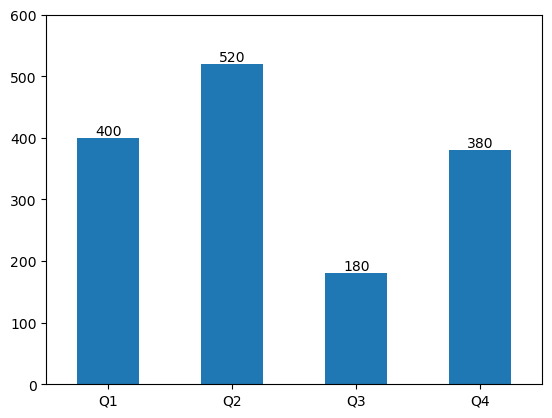

In [67]:
ser9 = pd.Series({'Q1': 400, 'Q2': 520, 'Q3': 180, 'Q4': 380})
ser9.plot(kind="bar")
#纵轴
plt.ylim(0,600)
#横轴
plt.xticks(rotation=0)
#为柱子添加标签
for i in range(ser9.size):
    plt.text(i, ser9[i] + 5, ser9[i], ha='center')
plt.show()

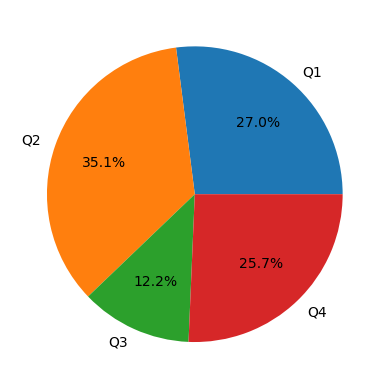

In [68]:
# plot方法的kind参数指定了图表类型为饼图
# autopct会自动计算并显示百分比
# pctdistance用来控制百分比到圆心的距离
ser9.plot(kind='pie', autopct='%.1f%%', pctdistance=0.65)
plt.show()